In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import sys
sys.path.append("../utils")
from indicators import compute_rsi

print("Ready")

Ready


In [2]:
# Load SPY with OHLCV
df = yf.download("SPY", start="2010-01-01",
                  end="2024-01-01", auto_adjust=True)
df.columns = df.columns.get_level_values(0)

price  = df["Close"].squeeze()
high   = df["High"].squeeze()
low    = df["Low"].squeeze()
volume = df["Volume"].squeeze()

# Load VIX
vix_raw = yf.download("^VIX", start="2010-01-01",
                       end="2024-01-01")
vix_raw.columns = vix_raw.columns.get_level_values(0)
vix = vix_raw["Close"].squeeze()
vix = vix.reindex(price.index).ffill()

log_returns = np.log(price / price.shift(1))

print(f"Loaded {len(price)} trading days")
print(f"Date range: {price.index[0].date()} to {price.index[-1].date()}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Loaded 3522 trading days
Date range: 2010-01-04 to 2023-12-29


In [3]:
def build_features(price, high, low, volume, vix):
    """
    Build feature matrix from technical indicators.
    All features use only data available at close T.
    Target: next-day return direction (shift -1).
    """
    feat = pd.DataFrame(index=price.index)

    # Momentum features
    feat['ret_1d']  = price.pct_change(1)
    feat['ret_5d']  = price.pct_change(5)
    feat['ret_10d'] = price.pct_change(10)
    feat['ret_20d'] = price.pct_change(20)
    feat['ret_60d'] = price.pct_change(60)

    # RSI features
    feat['rsi2']  = compute_rsi(price, period=2)
    feat['rsi14'] = compute_rsi(price, period=14)

    # Price vs moving averages
    sma20  = price.rolling(20).mean()
    sma50  = price.rolling(50).mean()
    sma200 = price.rolling(200).mean()
    feat['price_vs_sma20']  = (price - sma20)  / sma20
    feat['price_vs_sma50']  = (price - sma50)  / sma50
    feat['price_vs_sma200'] = (price - sma200) / sma200

    # Volatility features
    feat['vol_20d'] = log_returns.rolling(20).std() * np.sqrt(252)
    feat['vix']     = vix

    # ATR as % of price
    prev_close = price.shift(1)
    tr = pd.concat([high-low,
                    (high-prev_close).abs(),
                    (low-prev_close).abs()], axis=1).max(axis=1)
    feat['atr_pct'] = tr.rolling(14).mean() / price

    # Z-score
    feat['zscore_20'] = (price - sma20) / price.rolling(20).std()

    # Volume ratio
    feat['vol_ratio'] = volume / volume.rolling(20).mean()

    # Target: 1 if next-day return positive, 0 otherwise
    feat['target'] = (log_returns.shift(-1) > 0).astype(int)

    return feat.dropna()

features = build_features(price, high, low, volume, vix)

print(f"Feature matrix shape: {features.shape}")
print(f"Features: {[c for c in features.columns if c != 'target']}")
print(f"Target distribution:\n{features['target'].value_counts()}")

Feature matrix shape: (3323, 16)
Features: ['ret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'ret_60d', 'rsi2', 'rsi14', 'price_vs_sma20', 'price_vs_sma50', 'price_vs_sma200', 'vol_20d', 'vix', 'atr_pct', 'zscore_20', 'vol_ratio']
Target distribution:
target
1    1829
0    1494
Name: count, dtype: int64


In [4]:
# Time-ordered split — NEVER shuffle time series
split_date = "2018-01-01"

feature_cols = [c for c in features.columns if c != 'target']
X = features[feature_cols]
y = features['target']

X_train = X[X.index < split_date]
X_test  = X[X.index >= split_date]
y_train = y[y.index < split_date]
y_test  = y[y.index >= split_date]

print(f"Train: {len(X_train)} samples ({X_train.index[0].date()} to {X_train.index[-1].date()})")
print(f"Test : {len(X_test)} samples ({X_test.index[0].date()} to {X_test.index[-1].date()})")

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=4,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Evaluate on test set
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print(f"\nOOS Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Baseline (always predict up): {y_test.mean():.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Down', 'Up']))

Train: 1814 samples (2010-10-18 to 2017-12-29)
Test : 1509 samples (2018-01-02 to 2023-12-29)

OOS Accuracy: 0.536
Baseline (always predict up): 0.545

Classification Report:
              precision    recall  f1-score   support

        Down       0.43      0.06      0.10       686
          Up       0.54      0.93      0.69       823

    accuracy                           0.54      1509
   macro avg       0.49      0.50      0.40      1509
weighted avg       0.49      0.54      0.42      1509



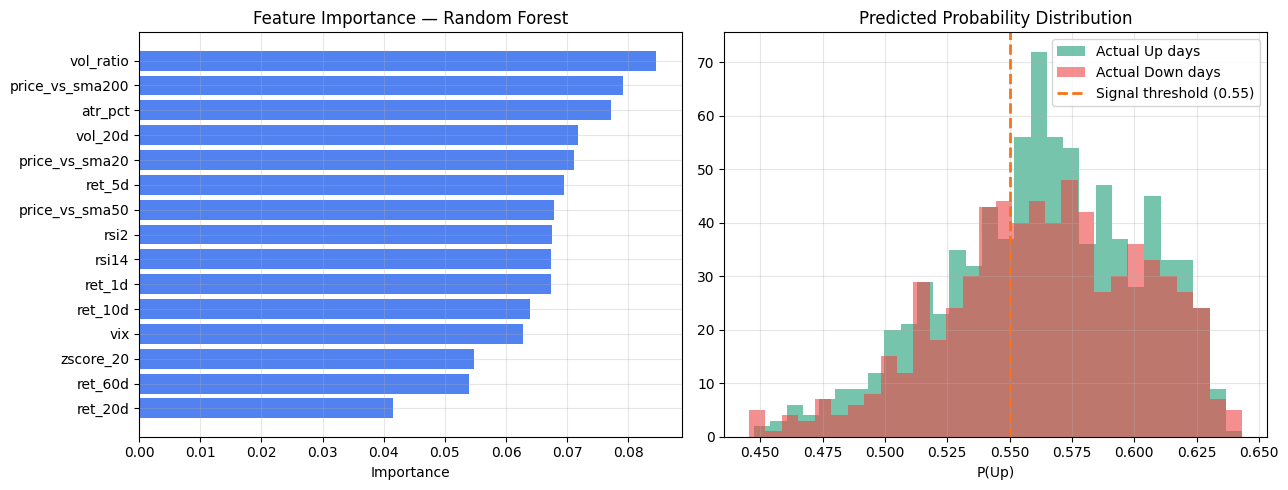


Top 5 most important features:
vol_ratio          0.084550
price_vs_sma200    0.079149
atr_pct            0.077220
vol_20d            0.071727
price_vs_sma20     0.071103


In [5]:
# Plot feature importance
feat_imp = pd.Series(rf.feature_importances_,
                     index=feature_cols).sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.barh(feat_imp.index[::-1], feat_imp.values[::-1],
         color='#2563eb', alpha=0.8)
ax1.set_title('Feature Importance — Random Forest')
ax1.set_xlabel('Importance')
ax1.grid(True, alpha=0.3)

# Probability distribution
ax2.hist(y_proba[y_test==1], bins=30, alpha=0.6,
         color='#1D9E75', label='Actual Up days')
ax2.hist(y_proba[y_test==0], bins=30, alpha=0.6,
         color='#ef4444', label='Actual Down days')
ax2.axvline(0.55, color='#f97316', lw=2,
            linestyle='--', label='Signal threshold (0.55)')
ax2.set_title('Predicted Probability Distribution')
ax2.set_xlabel('P(Up)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(feat_imp.head().to_string())


  ML SIGNAL BACKTEST — OOS 2018-2024
  Strategy                   Ann Ret  Ann Vol  Sharpe    Max DD Time Mkt
  -------------------------------------------------------------------
  ML Signal (p>0.55)         -24.58%   19.02%   -1.40   -80.26%    75.1%
  ML Signal (p>0.60)         -33.95%   15.35%   -2.34   -87.83%    28.5%
  Buy & Hold SPY              11.32%   20.46%    0.46   -35.75%    99.7%


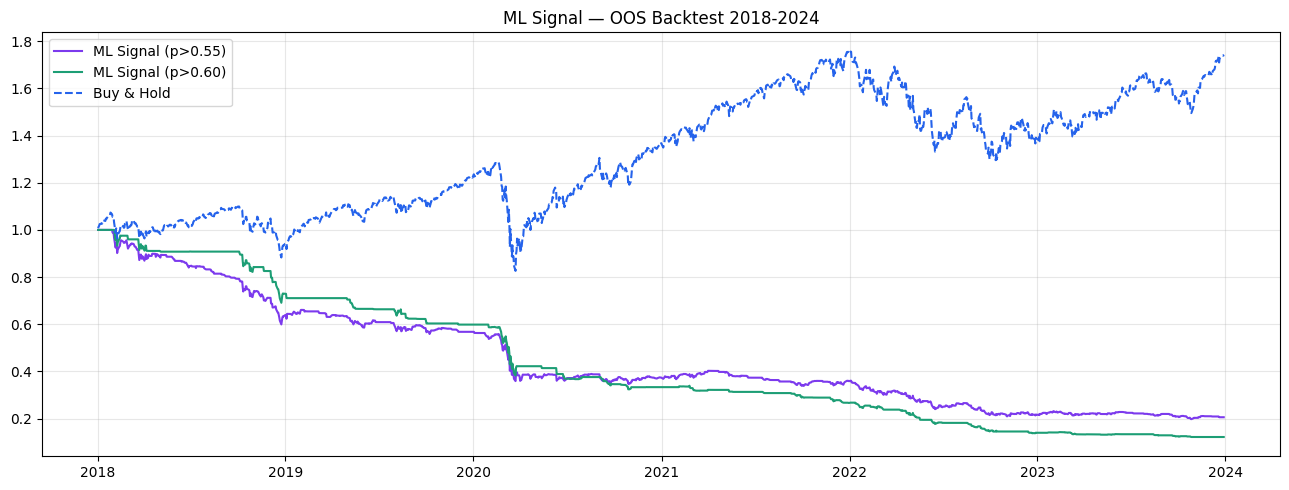

In [6]:
# Backtest ML signal on OOS data
signal = pd.Series((y_proba > 0.55).astype(int),
                    index=X_test.index)

# Get OOS returns
ret_oos = log_returns.reindex(X_test.index).fillna(0)

# Strategy returns
trades    = signal.diff().abs().fillna(0)
ml_ret    = signal * ret_oos - trades * 0.0006
bh_ret    = ret_oos.copy()

# High confidence only — proba > 0.60
signal_hc = pd.Series((y_proba > 0.60).astype(int),
                        index=X_test.index)
trades_hc = signal_hc.diff().abs().fillna(0)
ml_ret_hc = signal_hc * ret_oos - trades_hc * 0.0006

def perf(r, name):
    ar = r.mean() * 252
    av = r.std()  * np.sqrt(252)
    sh = (ar - 0.02) / av if av > 0 else 0
    w  = (1 + r).cumprod()
    dd = ((w - w.cummax()) / w.cummax()).min()
    tm = (r != 0).mean()
    print(f"  {name:<25} {ar:>8.2%} {av:>8.2%} {sh:>7.2f} {dd:>9.2%} {tm:>8.1%}")

print(f"\n{'='*72}")
print(f"  ML SIGNAL BACKTEST — OOS 2018-2024")
print(f"{'='*72}")
print(f"  {'Strategy':<25} {'Ann Ret':>8} {'Ann Vol':>8} {'Sharpe':>7} {'Max DD':>9} {'Time Mkt':>8}")
print(f"  {'-'*67}")
perf(ml_ret,    "ML Signal (p>0.55)")
perf(ml_ret_hc, "ML Signal (p>0.60)")
perf(bh_ret,    "Buy & Hold SPY")
print(f"{'='*72}")

# Plot OOS equity curves
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot((1+ml_ret).cumprod(),    color='#7c3aed', lw=1.5,
        label='ML Signal (p>0.55)')
ax.plot((1+ml_ret_hc).cumprod(), color='#1D9E75', lw=1.5,
        label='ML Signal (p>0.60)')
ax.plot((1+bh_ret).cumprod(),    color='#2563eb', lw=1.5,
        linestyle='--', label='Buy & Hold')
ax.set_title('ML Signal — OOS Backtest 2018-2024')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Check if inverse signal works
signal_inv    = 1 - signal
signal_inv_hc = 1 - signal_hc

trades_inv    = signal_inv.diff().abs().fillna(0)
trades_inv_hc = signal_inv_hc.diff().abs().fillna(0)
ml_ret_inv    = signal_inv    * ret_oos - trades_inv    * 0.0006
ml_ret_inv_hc = signal_inv_hc * ret_oos - trades_inv_hc * 0.0006

print(f"\n{'='*72}")
print(f"  INVERSE SIGNAL CHECK")
print(f"{'='*72}")
print(f"  {'Strategy':<25} {'Ann Ret':>8} {'Sharpe':>7} {'Max DD':>9}")
print(f"  {'-'*55}")
for r, name in [(ml_ret_inv,    "Inverse ML (p>0.55)"),
                (ml_ret_inv_hc, "Inverse ML (p>0.60)"),
                (bh_ret,        "Buy & Hold SPY")]:
    ar = r.mean()*252
    av = r.std()*np.sqrt(252)
    sh = (ar-0.02)/av if av>0 else 0
    w  = (1+r).cumprod()
    dd = ((w-w.cummax())/w.cummax()).min()
    print(f"  {name:<25} {ar:>8.2%} {sh:>7.2f} {dd:>9.2%}")
print(f"{'='*72}")

# Now let's check IS accuracy more carefully
y_pred_is  = rf.predict(X_train)
y_proba_is = rf.predict_proba(X_train)[:,1]
print(f"\nIS accuracy  : {accuracy_score(y_train, y_pred_is):.3f}")
print(f"OOS accuracy : {accuracy_score(y_test,  y_pred):.3f}")
print(f"\nThis gap reveals the model overfit to IS data")


  INVERSE SIGNAL CHECK
  Strategy                   Ann Ret  Sharpe    Max DD
  -------------------------------------------------------
  Inverse ML (p>0.55)         29.89%    3.87    -3.16%
  Inverse ML (p>0.60)         40.45%    2.92    -6.04%
  Buy & Hold SPY              11.32%    0.46   -35.75%

IS accuracy  : 0.604
OOS accuracy : 0.536

This gap reveals the model overfit to IS data


In [8]:
# Better approach: add regime features and use
# a more conservative model
features['vix_regime']    = (vix > 20).astype(int)
features['bull_regime']   = (price > price.rolling(200).mean()).astype(int)
features['vol_regime']    = (log_returns.rolling(20).std() >
                             log_returns.rolling(60).std()).astype(int)

feature_cols_v2 = feature_cols + ['vix_regime',
                                   'bull_regime',
                                   'vol_regime']
# Reindex features
features_v2 = build_features(price, high, low, volume, vix)
features_v2['vix_regime']  = (vix.reindex(features_v2.index) > 20).astype(int)
features_v2['bull_regime'] = (price.reindex(features_v2.index) >
                               price.rolling(200).mean().reindex(
                               features_v2.index)).astype(int)
features_v2['vol_regime']  = (log_returns.rolling(20).std().reindex(
                               features_v2.index) >
                               log_returns.rolling(60).std().reindex(
                               features_v2.index)).astype(int)

X2 = features_v2[[c for c in feature_cols + ['vix_regime',
                   'bull_regime','vol_regime']]]
y2 = features_v2['target']

X2_train = X2[X2.index < split_date]
X2_test  = X2[X2.index >= split_date]
y2_train = y2[y2.index < split_date]
y2_test  = y2[y2.index >= split_date]

# More conservative model — shallower trees
rf2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=3,
    min_samples_leaf=80,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf2.fit(X2_train, y2_train)

y2_pred  = rf2.predict(X2_test)
y2_proba = rf2.predict_proba(X2_test)[:,1]

print(f"V2 IS accuracy : {rf2.score(X2_train, y2_train):.3f}")
print(f"V2 OOS accuracy: {accuracy_score(y2_test, y2_pred):.3f}")
print(f"V2 IS-OOS gap  : {rf2.score(X2_train,y2_train)-accuracy_score(y2_test,y2_pred):.3f}")

# Backtest V2
signal_v2 = pd.Series((y2_proba > 0.55).astype(int),
                        index=X2_test.index)
trades_v2 = signal_v2.diff().abs().fillna(0)
ret_v2    = signal_v2 * ret_oos.reindex(
            signal_v2.index).fillna(0) - trades_v2 * 0.0006

ar = ret_v2.mean()*252
av = ret_v2.std()*np.sqrt(252)
sh = (ar-0.02)/av if av > 0 else 0
w  = (1+ret_v2).cumprod()
dd = ((w-w.cummax())/w.cummax()).min()

print(f"\nV2 Backtest OOS:")
print(f"  Ann Return : {ar:.2%}")
print(f"  Sharpe     : {sh:.2f}")
print(f"  Max DD     : {dd:.2%}")

V2 IS accuracy : 0.583
V2 OOS accuracy: 0.544
V2 IS-OOS gap  : 0.039

V2 Backtest OOS:
  Ann Return : -20.40%
  Sharpe     : -1.15
  Max DD     : -75.00%
